# Analyze a Distribution of an Existing Data
1. Score distribution per OSATS dimension
2. PRE and POST Split
3. Inter rater agreement
4. Novice, Intermediate, Proficient Split
5. Spearman correlation between all pair of dimension
6. How SUTURES is associated to GRS

NOTE: GRS = Global Rating Score

In [2]:
file = "../data/osats_score.csv"

## 1. Score Distribution per OSATS Dimension

In [4]:
import csv

evaluater_A = []
with open("../data/osats_score.csv", "r") as f:
    data = csv.reader(f)
    next(data)
    for row in data:
        if row[4] == 'A':
            evaluater_A.append(row)

print((evaluater_A[:1]))
print(len(evaluater_A))

[['AHO729', 'E-LEARNING', 'PRE', '1', 'A', 'P54M', '2', '1', '2', '2', '1', '2', '2', '1', '13']]
314


In [ ]:
# OSATS index = 6, 7, 8, 9, 10, 11, 12, 13
OSATS_index = {
    6: "Respect",
    7: "Motion",
    8: "Instrument",
    9: "Suture",
    10: "Flow",
    11: "Knowledge",
    12: "Performance",
    13: "Final Quality"
}

In [29]:
# Create an array that will count all of the spread of data
# count_all = [[0, 0, 0, 0, 0]] * 8 -- this will create ference to the same list and everything is modified
count_all = [[0, 0, 0, 0, 0] for _ in range(0,8)]

for i in range(0, 8):
    for item in evaluater_A:
        if item[6 + i] == '1':
            count_all[i][0] += 1
        elif item[6 + i] == '2':
            count_all[i][1] += 1
        elif item[6 + i] == '3':
            count_all[i][2] += 1
        elif item[6 + i] == '4':
            count_all[i][3] += 1
        else:
            count_all[i][4] += 1
    print(count_all)

[[101, 40, 81, 86, 6], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [108, 50, 80, 73, 3], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108, 52, 91, 61, 2], [108, 50, 80, 73, 3], [82, 58, 67, 86, 21], [0, 0, 0, 0, 0], [0, 0, 0, 0, 0]]
[[101, 40, 81, 86, 6], [113, 64, 108, 28, 1], [93, 47, 89, 76, 9], [108,

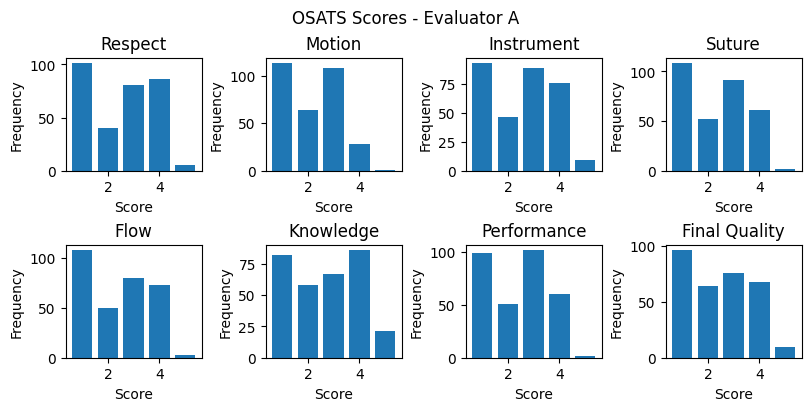

In [38]:
import matplotlib.pyplot as plt

names = ["Respect", "Motion", "Instrument", "Suture", "Flow", "Knowledge", "Performance", "Final Quality"]
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(8, 4), layout="constrained")
fig.suptitle("OSATS Scores - Evaluator A")

for x in range(2):
    for y in range(4):
        i = x * 4 + y
        categories = [1, 2, 3, 4, 5]
        values = count_all[i]
        axes[x, y].bar(categories, values)
        axes[x, y].set_title(names[i])
        axes[x, y].set_xlabel('Score')
        axes[x, y].set_ylabel('Frequency')
plt.show()

#### Lets combine everything together 

In [1]:
import csv
import matplotlib.pyplot as plt

def _read_based_on_evaluater(evaluater: str, file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    evaluater ('A', 'B', 'C') and csv file."""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[4] == evaluater:
                raw_score.append(row)
    return raw_score

def _score_distribution_per_osats(raw_score: list[list[str]]) -> list[list[int]]:
    """Return a list of all counts of score distribution per score."""
    count_all = [[0, 0, 0, 0, 0] for _ in range(0,8)]
    for i in range(0, 8):
        for item in raw_score:
            if item[6 + i] == '1':
                count_all[i][0] += 1
            elif item[6 + i] == '2':
                count_all[i][1] += 1
            elif item[6 + i] == '3':
                count_all[i][2] += 1
            elif item[6 + i] == '4':
                count_all[i][3] += 1
            else:
                count_all[i][4] += 1
    return count_all

def _plot_score_distribution(score_distribution: list[list[int]], title: str) -> None:
    """Print a firgure of 8 bar graphs for distribution for 8 OSTAS"""
    names = ["Respect", "Motion", "Instrument", "Suture",
             "Flow", "Knowledge", "Performance", "Final Quality"]
    fig, axes = plt.subplots(nrows=2, ncols=4,
                             figsize=(8, 4), layout="constrained")
    fig.suptitle(f"OSATS Score Distribution - Evaluator {title}")

    for x in range(2):
        for y in range(4):
            i = x * 4 + y
            categories = [1, 2, 3, 4, 5]
            values = score_distribution[i]
            axes[x, y].bar(categories, values)
            axes[x, y].set_title(names[i])
            axes[x, y].set_ylim(0, 150)
            axes[x, y].set_xlabel('Score')
            axes[x, y].set_ylabel('No of occurance')
    plt.show()

def plot_score_distribution_per_evaluater(file: str) -> None:
    """Read csv file, filter only an evaluater ('A', 'B', 'C'), then plot it"""
    # Plot data distribution for evaluater A
    raw_score = _read_based_on_evaluater('A', file)
    score_distribution = _score_distribution_per_osats(raw_score)
    _plot_score_distribution(score_distribution, 'A')

    # Plot data distribution for evaluater B
    raw_score = _read_based_on_evaluater('B', file)
    score_distribution = _score_distribution_per_osats(raw_score)
    _plot_score_distribution(score_distribution, 'B')

    # Plot data distribution for evaluater C
    raw_score = _read_based_on_evaluater('C', file)
    score_distribution = _score_distribution_per_osats(raw_score)
    _plot_score_distribution(score_distribution, 'C')

In [7]:
raw_score = _read_based_on_evaluater('C', file)
score_distribution = _score_distribution_per_osats(raw_score)
print(score_distribution)

[[53, 86, 142, 30, 3], [102, 100, 69, 39, 4], [113, 87, 76, 32, 6], [114, 66, 87, 39, 8], [103, 88, 74, 41, 8], [102, 54, 101, 46, 11], [112, 73, 80, 44, 5], [127, 58, 81, 40, 8]]


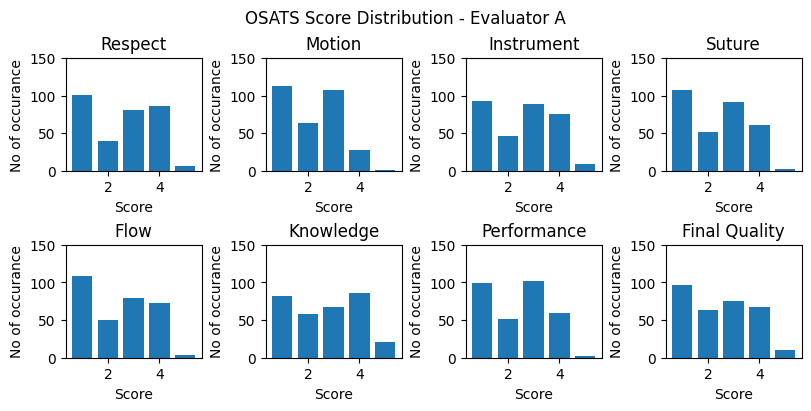

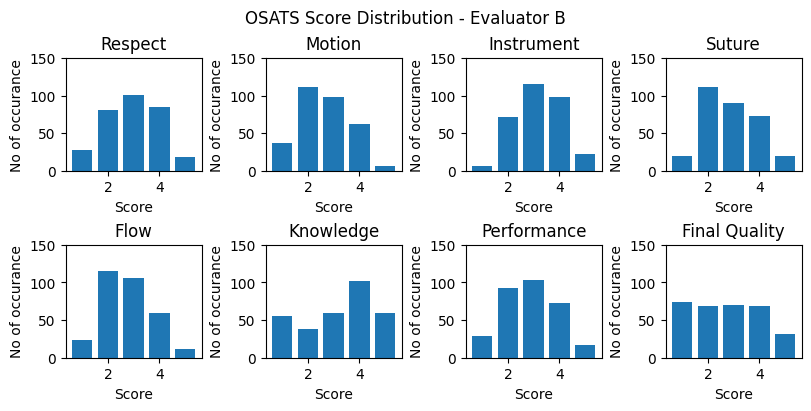

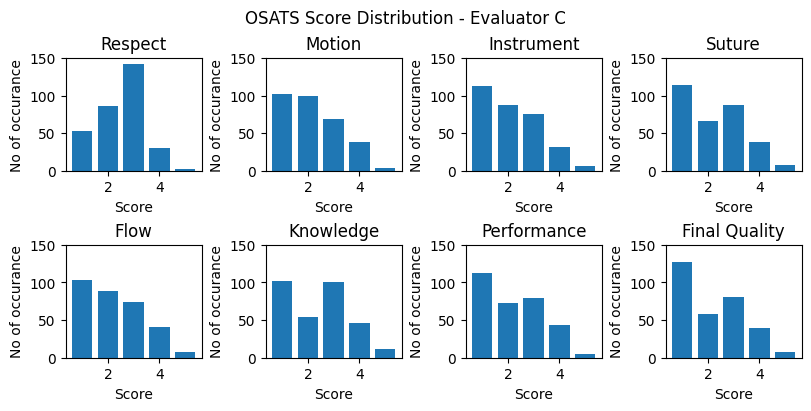

In [13]:
plot_score_distribution_per_evaluater(file)

## 2. PRE and POST Split

In [ ]:
import numpy as np

def _read_pre(file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    of only PRE tag"""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[2] == 'PRE':
                raw_score.append(row)
    return raw_score

def _read_post(file: str) -> list[list[str]]:
    """Return a list of list of score from a given
    of only POST tag"""
    raw_score = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for row in data:
            if row[2] == 'POST':
                raw_score.append(row)
    return raw_score

def _accumulate_grs(raw_score: list[list[str]]) -> list[int]:
    """Return a list of integers of grs form a raw_score"""
    accumulated_grs = []
    for item in raw_score:
        accumulated_grs.append(int(item[-1]))
    return accumulated_grs

def pre_post_stats_grs(file: str) -> dict:
    """Return a dictionary of mean grs"""
    output = {'PRE': {'mean': 0, 'median': 0},
                'POST': {'mean': 0, 'median': 0}}
    pre_raw_score = _read_pre(file)
    post_raw_score = _read_post(file)

    output['PRE']['mean'] = np.mean(_accumulate_grs(pre_raw_score))
    output['POST']['mean'] = np.mean(_accumulate_grs(post_raw_score))

    output['PRE']['median'] = np.median(_accumulate_grs(pre_raw_score))
    output['POST']['median'] = np.median(_accumulate_grs(post_raw_score))
    return output

In [17]:
pre_post_stats_grs(file)

{'PRE': {'mean': np.float64(14.097664543524417), 'median': np.float64(13.0)},
 'POST': {'mean': np.float64(26.537154989384288), 'median': np.float64(27.0)}}

## 3. Inter-rater Agreement
- what is an average agreement of 2 evaluaters: A, B, C
- calculate it robustly with Krippendorff's alpha 

Krippendorff's alpha :
- α = 1: Perfect reliability and agreement among all raters.
- α = 0: Agreement equals what is expected by random chance (no reliability).
- α < 0: Systematic disagreement, worse than random chance.

The input data that is required should look like this: 
| Evaluator | AHO729 | AHO730 |
|-----------|--------|--------|
| A         | 13     | 15     |
| B         | 13     | 14     |
| C         | 9      | 15     |

In [5]:
import csv
import krippendorff

def _read_grs_and_rater(file: str) -> list[list]:
    """Return a list of list representing matrix for krippendorff.alpha
    function: column = video, row = evaluater
    row 0 -- A
    row 1 -- B
    row 2 -- C
    """
    grs_and_rater_data = [[] for _ in range(0, 3)]
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for item in data:
            if item[4] == 'A':
                grs_and_rater_data[0].append(int(item[-1]))
            elif item[4] == 'B':
                grs_and_rater_data[1].append(int(item[-1]))
            elif item[4] == 'C':
                grs_and_rater_data[2].append(int(item[-1]))
    return grs_and_rater_data

def calculate_krippendorff_alpha(file: str) -> None:
    """Report Krippendorff's alpha value for reliability of
    3 evaluaters from the input csv file"""
    grs_data = _read_grs_and_rater(file)
    grs_AB = [grs_data[0], grs_data[1]]
    grs_AC = [grs_data[0], grs_data[2]]
    grs_BC = [grs_data[1], grs_data[2]]

    # Calculate Krippendorff's Alpha -- for non-nominal data
    alpha_value = krippendorff.alpha(
        reliability_data=grs_data,
        level_of_measurement="ordinal"
    )
    alpha_AB = krippendorff.alpha(reliability_data=grs_AB,
                                  level_of_measurement="ordinal")
    alpha_AC = krippendorff.alpha(reliability_data=grs_AC,
                                  level_of_measurement="ordinal")
    alpha_BC = krippendorff.alpha(reliability_data=grs_BC,
                                  level_of_measurement="ordinal")

    print("-------------------------------------------")
    print(f"Krippendorff's alpha = {alpha_value}")
    print("-------------------------------------------")

    print(f"Krippendorff's alpha A-B= {alpha_AB}")
    print(f"Krippendorff's alpha A-C= {alpha_AC}")
    print(f"Krippendorff's alpha B-C= {alpha_BC}")

    print("-------------------------------------------")
    print("Overall Interpretation:")
    if alpha_value == 1.0:
        print("Perfect agreement")
    elif alpha_value >= 0.8:
        print("Strong agreement (generally acceptable)")
    elif alpha_value >= 0.67:
        print("Tentative conclusions may be acceptable")
    elif alpha_value >= 0.0:
        print("Poor agreement")
    elif alpha_value == 0.0:
        print("Agreement is no better than chance")
    else:
        print("Worse than chance")

    print("-------------------------------------------")

In [48]:
calculate_krippendorff_alpha(file)

-------------------------------------------
Krippendorff's alpha = 0.7317541125163405
-------------------------------------------
Krippendorff's alpha A-B= 0.7277549614345622
Krippendorff's alpha A-C= 0.8038437606741642
Krippendorff's alpha B-C= 0.6487823288850824
-------------------------------------------
Overall Interpretation:
Tentative conclusions may be acceptable
-------------------------------------------


## 4. Novice, Intermediate, Proficient Split

Definition of each from the paper:
- proficient GRS ≥ 24
- intermediate skill levels 16 ≤ GRS < 24
- novice GRS < 16

In [ ]:
# use _read_grs_and_rater to read obtain the data from a given file

def count_skill_level(file: str) -> dict:
    """Return a dictionary counting how many videos spread
    there are for each skill level"""
    grs_and_rater_data = _read_grs_and_rater(file)
    skill_spread = {0: {'novice': 0, 'intermediate': 0, 'proficient': 0},
                    1: {'novice': 0, 'intermediate': 0, 'proficient': 0},
                    2: {'novice': 0, 'intermediate': 0, 'proficient': 0}}
    for i in range(0, 3):
        for grs in grs_and_rater_data[i]:
            if grs >= 24:
                skill_spread[i]['proficient'] += 1
            elif grs >= 16:
                skill_spread[i]['intermediate'] += 1
            else:
                skill_spread[i]['novice'] += 1
    return skill_spread

In [6]:
count_skill_level(file)

{0: {'novice': 122, 'intermediate': 57, 'proficient': 135},
 1: {'novice': 63, 'intermediate': 103, 'proficient': 148},
 2: {'novice': 139, 'intermediate': 88, 'proficient': 87}}

Next step: take a look what are all the videos that agree in terms of proficiency level

In [ ]:
# Lets see the distribution of data if I take average grs instead
def count_average_skill_level(file: str) -> dict:
    """Return dictionary of three level count"""
    output = {'novice': 0, 'intermediate': 0, 'proficient': 0}
    grs_and_rater_data = _read_grs_and_rater(file)
    for i in range(0, 314):
        avg_grs = sum(grs_and_rater_data[j][i] for j in range(0, 3))/3
        if avg_grs >= 24:
            output['proficient'] += 1
        elif avg_grs >= 16:
            output['intermediate'] += 1
        else:
            output['novice'] += 1
    return output

In [12]:
count_average_skill_level(file)

{'novice': 116, 'intermediate': 74, 'proficient': 124}

In [21]:
# Lets see the distribution of average grs but only PRE & POST separately

import csv

def _read_grs_and_rater(type: str, file: str) -> list[list]:
    """Return a list of list representing matrix for krippendorff.alpha
    function: column = video, row = evaluater
    row 0 -- A
    row 1 -- B
    row 2 -- C
    input:
    - type: 'PRE' or 'POST'
    """
    avg_grs_and_rater_data = [[] for _ in range(0, 3)]
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for item in data:
            if item[2] == type:
                if item[4] == 'A':
                    avg_grs_and_rater_data[0].append(int(item[-1]))
                elif item[4] == 'B':
                    avg_grs_and_rater_data[1].append(int(item[-1]))
                elif item[4] == 'C':
                    avg_grs_and_rater_data[2].append(int(item[-1]))
    return avg_grs_and_rater_data

def count_average_skill_level_pre_post(file: str) -> dict:
    """Return dictionary of three level count"""
    output_pre = {'novice': 0, 'intermediate': 0, 'proficient': 0}
    output_post = {'novice': 0, 'intermediate': 0, 'proficient': 0}

    avg_grs_pre = _read_grs_and_rater('PRE', file)
    avg_grs_post = _read_grs_and_rater('POST', file)

    for i in range(0, len(avg_grs_pre[0])):
        avg_grs = sum(avg_grs_pre[j][i] for j in range(0, 3))/3
        if avg_grs >= 24:
            output_pre['proficient'] += 1
        elif avg_grs >= 16:
            output_pre['intermediate'] += 1
        else:
            output_pre['novice'] += 1

    for i in range(0, len(avg_grs_post[0])):
            avg_grs = sum(avg_grs_post[j][i] for j in range(0, 3))/3
            if avg_grs >= 24:
                output_post['proficient'] += 1
            elif avg_grs >= 16:
                output_post['intermediate'] += 1
            else:
                output_post['novice'] += 1
    print(f"PRE: {output_pre}")
    print(f"POST: {output_post}")

In [22]:
count_average_skill_level_pre_post(file)

PRE: {'novice': 114, 'intermediate': 36, 'proficient': 7}
POST: {'novice': 2, 'intermediate': 38, 'proficient': 117}


## 5. Spearman correlation between all pair of dimension

In [ ]:
import csv
from scipy.stats import spearmanr
import seaborn as sns

def _read_row_of_vid(file: str) -> list[list[int]]:
    """Return a list of score in the given file,
    which a row is videos and column is osats"""
    row_of_vid_data = []
    with open(file, "r") as f:
        data = csv.reader(f)
        next(data)
        for item in data:
            row_of_vid_data.append([int(item[6 + i]) for i in range(0, 8)])
    return row_of_vid_data

def _calculate_correlation(row_of_vid_data: list[list[int]]) -> tuple:
    """Return a tuple of matrix of correlation values
    and matrix of p_values"""
    row_of_vid_data = _read_row_of_vid(file)
    correlation_matrix, p_values = spearmanr(row_of_vid_data)
    return correlation_matrix, p_values

def visualize_correlation_pvals(file:str) -> None:
    """Print out a correlation and pvalues heatmap"""
    osats_labels = ["Respect", "Motion", "Instrument", "Suture", "Flow",
                    "Knowledge", "Performance", "Final Quality"]

    row_of_vid_data = _read_row_of_vid(file)
    correlation_matrix, p_values = _calculate_correlation(row_of_vid_data)

    # Correlation plot
    plt.figure(figsize=(8, 8))
    sns.heatmap(
        correlation_matrix,
        annot=True,  # Display the numbers inside each cell
        fmt=".2f",  # Format numbers to 2 decimal places
        cmap="coolwarm",  # Choose a color palette (e.g., 'viridis', 'YlGnBu')
        linewidths=0.5,  # Add a thin border between cells
        square=True,  # Force cells to be perfect squares
        xticklabels=osats_labels,
        yticklabels=osats_labels
    )
    plt.title("P_values for each OSATS rubric")
    plt.show()

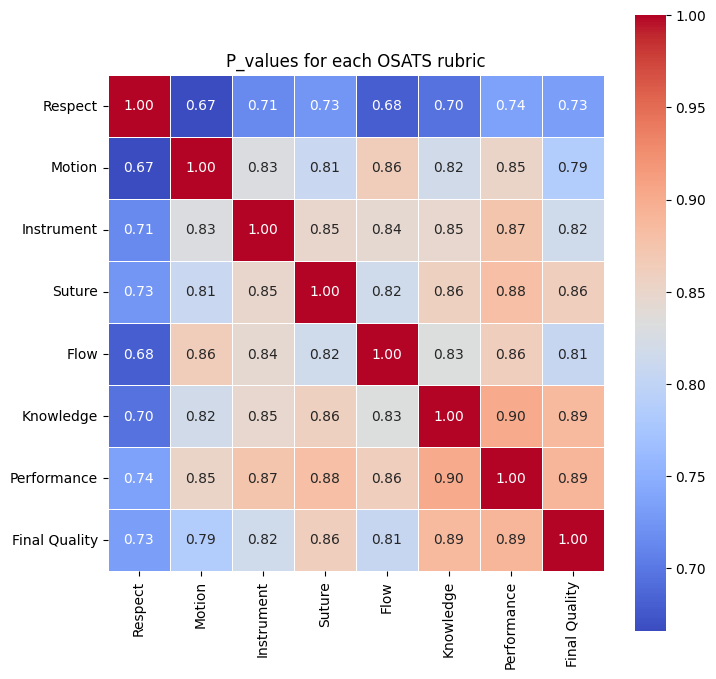

In [24]:
visualize_correlation_pvals(file)

Top correlated pairs
1. Knowledge - Performance (Both are subjective)
2. Knowledge - Final quality
3. Performac - Final quality
4. Suture - Performance

## Distinct glove color split 

In [22]:
# prepare a csv file to classify different blue colors

import csv
file = "../data/osats_score.csv"
new_file = "../data/color.csv"
duplicate = []
with open(file, "r") as f:
    data = csv.reader(f)
    next(data)
    with open(new_file, "w") as ff:
        ff.write("vid_id, color \n")
        for item in data:
            if item[5] not in duplicate:
                duplicate.append(item[5])
        for item in sorted(duplicate):
            ff.write(item + ", \n")

In [ ]:
# read the annoateated csv file to count amount for each type
# check ../assets/color_definition.png for color definition
import csv
count = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0}
file = "../data/color.csv"
with open(file, "r") as f:
    data = csv.reader(f)
    next(data)
    for line in data:
        # print(line)
        if int(line[1]) in count:
            count[int(line[1])] += 1
print(count)

{1: 2, 2: 106, 3: 6, 4: 21, 5: 119, 6: 58, 7: 2}


314 PRE videos
- 218 train -- 70% --- {1: 1, 2: 74, 3: 4, 4: 15, 5: 83, 6: 40, 7: 1}
- 49 val -- 15% ------ {1: 1, 2: 16, 3: 1, 4: 3, 5: 18, 6: 9, 7: 1}
- 47 test -- 15% ----- {1: 0, 2: 16, 3: 1, 4: 3, 5: 18, 6: 9, 7: 0}

In [6]:
# lets define what videos for train and val
import csv
train_count = {1: 1, 2: 74, 3: 4, 4: 15, 5: 83, 6: 40, 7: 1}
val_count = {1: 1, 2: 16, 3: 1, 4: 3, 5: 18, 6: 9, 7: 1}
test_count = {1: 0, 2: 16, 3: 1, 4: 3, 5: 18, 6: 9, 7: 0}

train = []
val = []
test = []

color_file = "../data/color.csv"
with open(color_file, "r") as cf:
    data = csv.reader(cf)
    next(data)
    for line in data:
        vid_id = line[0]
        color = int(line[1])
        if train_count[color] != 0:
            train.append(vid_id)
            train_count[color] -= 1
        elif val_count[color] != 0:
            val.append(vid_id)
            val_count[color] -= 1
        else:
            test.append(vid_id)
            test_count[color] -= 1

In [8]:
print("----- TOTAL SPLIT -----")
print(f"TRAIN ({len(train)}): {train}")
print(f"VAL ({len(val)}): {val}")
print(f"TEST ({len(test)}): {test}")

----- TOTAL SPLIT -----
TRAIN (218): ['A31H', 'A36O', 'A40E', 'A41X', 'A59Z', 'A61V', 'A66S', 'A80U', 'A83X', 'A88O', 'A92O', 'A99X', 'A99Y', 'B12G', 'B36R', 'B53D', 'B61D', 'B68G', 'B88L', 'C16G', 'C18X', 'C28D', 'C33I', 'C36X', 'C42I', 'C43T', 'C46R', 'C48S', 'C58C', 'C65K', 'C85C', 'C85Q', 'D04V', 'D12Y', 'D16B', 'D17H', 'D35B', 'D39G', 'D44W', 'D51V', 'D59F', 'D65L', 'D82C', 'D94Z', 'E01L', 'E04A', 'E23G', 'E39Z', 'E45Q', 'E47O', 'E63M', 'E66F', 'E82Z', 'E86N', 'F03Z', 'F10I', 'F32Q', 'F36V', 'F48S', 'F66E', 'F66N', 'F75X', 'F77P', 'F88K', 'F95D', 'G11V', 'G21B', 'G21U', 'G22R', 'G32E', 'G61C', 'G61O', 'G66T', 'G86B', 'G92L', 'G93D', 'G94Z', 'H11P', 'H13A', 'H22T', 'H27O', 'H33Z', 'H50P', 'H71D', 'H87Y', 'I01F', 'I23K', 'I24C', 'I26T', 'I33C', 'I39S', 'I45Y', 'I58N', 'I58X', 'I67J', 'I70X', 'I77J', 'I92X', 'I97U', 'J76I', 'J77I', 'J78O', 'J83Z', 'J87K', 'J88T', 'J96P', 'K11Q', 'K12K', 'K16O', 'K21K', 'K32I', 'K32R', 'K43N', 'K43V', 'K53Y', 'K55R', 'K56C', 'K71Q', 'K75R', 'K78J', 'K

In [ ]:
# lets use the data that we have to extract 3 frames for creating a mask
# make a folder train, val, test with 3 frames of videos in

In [9]:
import os
import cv2
import numpy as np
from pathlib import Path


# ── Config — update these two paths ───────────────────────────────────────────
VIDEO_DIR   = "/Volumes/Golden_PP/suture/all_videos"   # folder that contains the .mp4 files
OUTPUT_DIR  = "../frame_splits"         # where train/val/test folders will be created
NUM_FRAMES  = 3                        # number of frames to extract per video
VIDEO_EXTS  = {".mp4", ".avi", ".mov", ".mkv"}  # recognised video extensions
# ──────────────────────────────────────────────────────────────────────────────


def extract_frames(video_path: str, out_dir: str, n_frames: int = 3) -> list[str]:
    """
    Extract n_frames evenly-spaced frames from video_path and save them as
    PNGs inside out_dir.  Returns a list of saved file paths.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise IOError(f"Cannot open video: {video_path}")

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames < n_frames:
        # If video is shorter than requested, sample all available frames
        indices = list(range(total_frames))
    else:
        # Evenly spaced: e.g. for 3 frames → 25 %, 50 %, 75 % positions
        indices = [int(total_frames * (i + 1) / (n_frames + 1)) for i in range(n_frames)]

    video_id   = Path(video_path).stem
    saved      = []

    for rank, idx in enumerate(indices, start=1):
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            print(f"  ⚠  Could not read frame {idx} from {video_id}")
            continue
        out_path = os.path.join(out_dir, f"{video_id}_frame{rank:02d}.png")
        cv2.imwrite(out_path, frame)
        saved.append(out_path)

    cap.release()
    return saved


def find_video(video_id: str, video_dir: str) -> str | None:
    """Return the full path of the video whose stem matches video_id, or None."""
    for ext in VIDEO_EXTS:
        candidate = os.path.join(video_dir, f"{video_id}{ext}")
        if os.path.isfile(candidate):
            return candidate
    return None


def process_split(split_name: str, ids: list[str], video_dir: str, output_dir: str):
    split_dir = os.path.join(output_dir, split_name)
    os.makedirs(split_dir, exist_ok=True)

    found, missing, total_frames = 0, 0, 0

    print(f"\n{'='*55}")
    print(f"  Processing {split_name.upper()} ({len(ids)} videos)")
    print(f"{'='*55}")

    for vid_id in ids:
        video_path = find_video(vid_id, video_dir)
        if video_path is None:
            print(f"  ✗ NOT FOUND : {vid_id}")
            missing += 1
            continue
        try:
            saved = extract_frames(video_path, split_dir, NUM_FRAMES)
            print(f"  ✓ {vid_id:8s} → {len(saved)} frames saved")
            total_frames += len(saved)
            found += 1
        except Exception as e:
            print(f"  ✗ ERROR ({vid_id}): {e}")
            missing += 1

    print(f"\n  Summary: {found} videos processed, "
          f"{total_frames} frames saved, {missing} videos not found.")


# ── Run ───────────────────────────────────────────────────────────────────────
splits = {
    "train": train,
    "val":   val,
    "test":  test,
}

for split_name, ids in splits.items():
    process_split(split_name, ids, VIDEO_DIR, OUTPUT_DIR)

print(f"\n✅ Done. Frames saved to: {os.path.abspath(OUTPUT_DIR)}")
print(f"   Structure:  {OUTPUT_DIR}/train/  |  val/  |  test/")



  Processing TRAIN (218 videos)
  ✓ A31H     → 3 frames saved
  ✓ A36O     → 3 frames saved
  ✓ A40E     → 3 frames saved
  ✓ A41X     → 3 frames saved
  ✓ A59Z     → 3 frames saved
  ✓ A61V     → 3 frames saved
  ✓ A66S     → 3 frames saved
  ✓ A80U     → 3 frames saved
  ✓ A83X     → 3 frames saved
  ✓ A88O     → 3 frames saved
  ✓ A92O     → 3 frames saved
  ✓ A99X     → 3 frames saved
  ✓ A99Y     → 3 frames saved
  ✓ B12G     → 3 frames saved
  ✓ B36R     → 3 frames saved
  ✓ B53D     → 3 frames saved
  ✓ B61D     → 3 frames saved
  ✓ B68G     → 3 frames saved
  ✓ B88L     → 3 frames saved
  ✓ C16G     → 3 frames saved
  ✓ C18X     → 3 frames saved
  ✓ C28D     → 3 frames saved
  ✓ C33I     → 3 frames saved
  ✓ C36X     → 3 frames saved
  ✓ C42I     → 3 frames saved
  ✓ C43T     → 3 frames saved
  ✓ C46R     → 3 frames saved
  ✓ C48S     → 3 frames saved
  ✓ C58C     → 3 frames saved
  ✓ C65K     → 3 frames saved
  ✓ C85C     → 3 frames saved
  ✓ C85Q     → 3 frames saved
  ✓ D04